# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [135]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
# YOUR CODE HERE

# 2. Acquire and load your primary dataset
# YOUR CODE HERE

In [136]:
# Folder
print(f"Current working directory: {os.getcwd()}")

# List Files
print("\nFiles in current folder:")
print(os.listdir("."))

# List Files 2 Levels Up
print(os.listdir("../"))

Current working directory: c:\Users\hayde\Documents\GitHub\datascience-publicpolicy-2026\notebooks\hw\hw_3

Files in current folder:
['hw_3.ipynb', 'social-media-users-by-country-2026.csv']
['cory-baird.ipynb', 'hayden-hubbard.ipynb', 'hw_1.ipynb', 'hw_2', 'hw_3']


In [137]:
# Load World Happiness Report Cleaned Dataset
url = "https://raw.githubusercontent.com/ahshah322/World-Happiness-Report-2025/refs/heads/main/data/WHR_2025.csv"
happiness = pd.read_csv(url)
happiness.head()

,Country name,Regional indicator,Ladder score,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
0,Singapore,Southeast Asia,6.565,2.022,1.565,0.935,0.856,0.164,0.522
1,Finland,Western Europe,7.736,1.749,1.783,0.824,0.986,0.110,0.502
2,Denmark,Western Europe,7.521,1.825,1.748,0.820,0.955,0.150,0.488
3,Switzerland,Western Europe,6.935,1.870,1.622,0.883,0.889,0.156,0.468
4,Sweden,Western Europe,7.345,1.783,1.698,0.889,0.952,0.170,0.467


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *World Happiness Report 2025 Data*

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [ ]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE

In [138]:
happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                147 non-null    object 
 1   Regional indicator                          147 non-null    object 
 2   Ladder score                                147 non-null    float64
 3   Explained by: Log GDP per capita            147 non-null    float64
 4   Explained by: Social support                147 non-null    float64
 5   Explained by: Healthy life expectancy       146 non-null    float64
 6   Explained by: Freedom to make life choices  146 non-null    float64
 7   Explained by: Generosity                    147 non-null    float64
 8   Explained by: Perceptions of corruption     146 non-null    float64
dtypes: float64(7), object(2)
memory usage: 10.5+ KB


In [139]:
# Test 
happiness.head(3)

,Country name,Regional indicator,Ladder score,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
0,Singapore,Southeast Asia,6.565,2.022,1.565,0.935,0.856,0.164,0.522
1,Finland,Western Europe,7.736,1.749,1.783,0.824,0.986,0.110,0.502
2,Denmark,Western Europe,7.521,1.825,1.748,0.820,0.955,0.150,0.488


In [140]:
# 2. Rename columns and select a clean subset
happiness = happiness.rename({"Ladder score": "Happiness Score", "Country name": "Country"}, axis=1)
happiness = happiness[["Country", "Happiness Score"]]
happiness.head(3)

,Country,Happiness Score
0,Singapore,6.565
1,Finland,7.736
2,Denmark,7.521


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [141]:
# 1. Load and clean the secondary dataset
# Social Media Users By Country
path = "social-media-users-by-country-2026.csv"
social = pd.read_csv(path)
social.head(2)
#social = 'SOCIAL MEDIA'

,flagCode,country,SocialMediaUsers_2025,SocialMediaUsersPctOfPopulation_2025
0,CN,China,1280000000,90.3
1,IN,India,500000000,34.1


In [142]:
social = social.rename({"country": "Country", "SocialMediaUsersPctOfPopulation_2025": "SMedia and Percentage of Pop 2025"}, axis=1)
social = social[["Country", "SMedia and Percentage of Pop 2025"]]
social.head(3)

,Country,SMedia and Percentage of Pop 2025
0,China,90.3
1,India,34.1
2,United States,73.0


In [143]:
%whos

Variable         Type                        Data/Info
------------------------------------------------------
X_real           Series                      Shape: (135,)
X_real_const     DataFrame                   Shape: (135, 2)
df               DataFrame                   Shape: (231, 2)
df_merged        DataFrame                   Shape: (135, 3)
group_means      Series                      Shape: (4,)
happiness        DataFrame                   Shape: (147, 2)
intercept_real   float64                     3.6066465761808932
merge_data       function                    <function merge_data at 0x0000015C155A0900>
model_real       RegressionResultsWrapper    <statsmodels.regression.l<...>ct at 0x0000015C185C11D0>
os               module                      <module 'os' (frozen)>
path             str                         social-media-users-by-country-2026.csv
pd               module                      <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt              module

In [144]:
# 2. Merge your datasets on a common key
def merge_data(df_happiness, df_social):
    # YOUR CODE HERE
    df_merge = pd.merge(
        df_happiness,
        df_social,
        on="Country",
        how="inner"
    )
    return df_merge

df_merged = merge_data(happiness, social)
df_merged.head()

,Country,Happiness Score,SMedia and Percentage of Pop 2025
0,Singapore,6.565,90.6
1,Finland,7.736,72.9
2,Denmark,7.521,78.9
3,Switzerland,6.935,81.0
4,Sweden,7.345,80.4


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Country is the Common Merge Key. As I am comparing Happiness with Social Media Usage by a Countries' population, I kept those columns as well.*

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [145]:
# Apply groupby aggregation or implement one of the backup grouping strategies

# Creates Groups Based on Social Media Usage
df_merged["SMedia and Percentage of Pop 2025"] = pd.cut(
    df_merged["SMedia and Percentage of Pop 2025"],
    bins=[0, 25, 50, 75, 100],
    labels=["Minimal", "Low", "Medium", "High"]
)

In [146]:
df_merged.groupby("SMedia and Percentage of Pop 2025")["Happiness Score"].mean()

C:\Users\hayde\AppData\Local\Temp\ipykernel_40460\3966518592.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_merged.groupby("SMedia and Percentage of Pop 2025")["Happiness Score"].mean()


SMedia and Percentage of Pop 2025
Minimal    4.133615
Low        4.773750
Medium     5.947340
High       6.392750
Name: Happiness Score, dtype: float64

In [147]:
df_merged["SMedia and Percentage of Pop 2025"].value_counts()

SMedia and Percentage of Pop 2025
Medium     47
High       40
Minimal    26
Low        20
Name: count, dtype: int64

In [148]:
df_merged[[
    "Country",
    "Happiness Score",
    "SMedia and Percentage of Pop 2025",
]].head(20)

,Country,Happiness Score,SMedia and Percentage of Pop 2025
0,Singapore,6.565,High
1,Finland,7.736,Medium
2,Denmark,7.521,High
3,Switzerland,6.935,High
4,Sweden,7.345,High
5,New Zealand,6.952,High
6,Norway,7.262,High
7,Luxembourg,7.122,Low
8,Ireland,6.889,High
9,Estonia,6.417,High


- *Extra Credit: Write your economic or policy related interpretation here*
As countries have more social media usage, their happiness appears to be higher. This is likely not solely due to social media, and more likely, is a sign of general technological adoption.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

C:\Users\hayde\AppData\Local\Temp\ipykernel_40460\2831951018.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df_merged.groupby("SMedia and Percentage of Pop 2025")["Happiness Score"].mean()


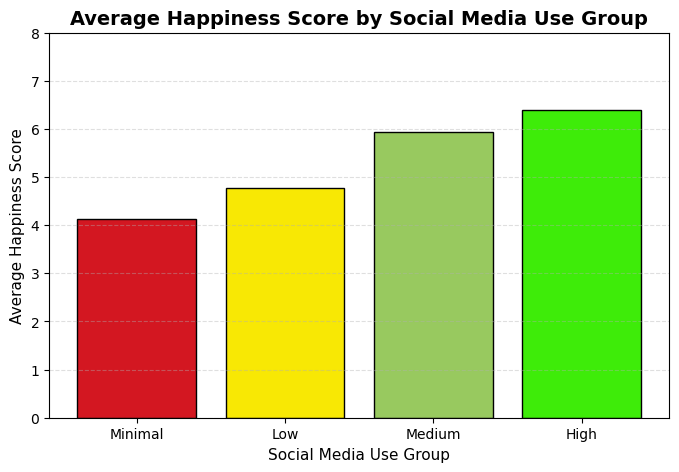

In [149]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
import matplotlib.pyplot as plt

# Calculate average happiness by social media group
group_means = df_merged.groupby("SMedia and Percentage of Pop 2025")["Happiness Score"].mean()

# Reorder the categories
group_means = group_means.reindex(["Minimal", "Low", "Medium", "High"])

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    group_means.index,
    group_means.values,
    color=["#d31721", "#f8e804", "#98c95f", "#3eec09"],
    edgecolor="black"
)

plt.title("Average Happiness Score by Social Media Use Group", fontsize=14, fontweight="bold")
plt.xlabel("Social Media Use Group", fontsize=11)
plt.ylabel("Average Happiness Score", fontsize=11)

plt.ylim(0, 8)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [150]:
# Plot 2: Customized scatter plot of primary policy variables
df_merged = merge_data(happiness, social)


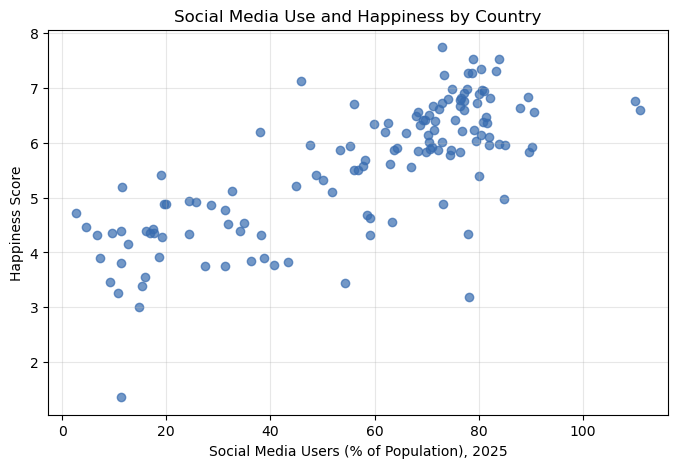

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df_merged["SMedia and Percentage of Pop 2025"],
    df_merged["Happiness Score"],
    color="#386cb0",
    alpha=0.7
)

plt.title("Social Media Use and Happiness by Country")
plt.xlabel("Social Media Users (% of Population), 2025")
plt.ylabel("Happiness Score")
plt.grid(True, alpha=0.3)

plt.show()

In [152]:
# Fit a simple linear regression and overlay the line of best fit
import statsmodels.api as sm

# Keep original setup: Happiness predicts GDP
X_real = df_merged['SMedia and Percentage of Pop 2025']
y_real = df_merged['Happiness Score']
X_real_const = sm.add_constant(X_real)
X_real_const.head(2)

,const,SMedia and Percentage of Pop 2025
0,1.0,90.6
1,1.0,72.9


In [153]:
model_real = sm.OLS(y_real, X_real_const).fit()
model_real

In [154]:
intercept_real, slope_real = model_real.params.iloc[0], model_real.params.iloc[1]

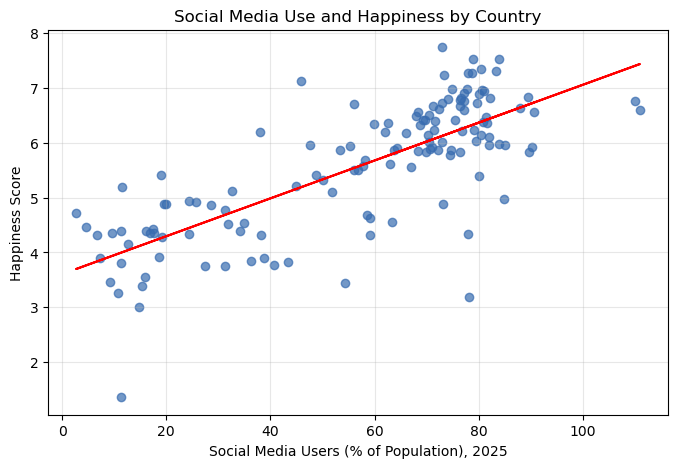

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df_merged["SMedia and Percentage of Pop 2025"],
    df_merged["Happiness Score"],
    color="#386cb0",
    alpha=0.7
)

plt.title("Social Media Use and Happiness by Country")
plt.xlabel("Social Media Users (% of Population), 2025")
plt.ylabel("Happiness Score")
plt.grid(True, alpha=0.3)

plt.plot(df_merged['SMedia and Percentage of Pop 2025'], intercept_real + slope_real * df_merged['SMedia and Percentage of Pop 2025'], color='red', label='OLS Best Fit Regression Line')

plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*
Similar to the last section, it appears that the percentage of social media users is correlated with the happiness of the population. This is likely due to an array of other factors, such as general technology advancement and adoption in the country, and is likely not causative. (Though, social media companies would probably be happy to see such)